In [1]:
# Test to load one pickle file
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from lameg.laminar import compute_csd
from lameg.viz import plot_csd

In [2]:
filepath = '/home/sgailhard/Documents/laminar_meg/laminar_csd_method/simulations/2_double_dipole/2_consecutive/cluster/sim_2_consec_sources'
filename = 'vx27692_2_consec_sources_width10_tmp_dist50_win_size10.pickle'

with open(os.path.join(filepath, filename), 'rb') as f:
    data = pickle.load(f)

In [3]:
data

{'sim_vertex': 27692,
 'n_layers': 11,
 'sim_layers': [(1, 9), (3, 7)],
 'patch_size': 5,
 'err_level': 0,
 'sim_patch_size': 5,
 'n_temp_modes_ebb': 4,
 'n_spatial_modes': 'auto',
 'hann_windowing_ebb': False,
 'snr': 0,
 'dipole_moment': [10, 10],
 'signal_width': 10,
 'sim_signal': array([[3.59269129e-23, 1.92874985e-22, 1.00708974e-21, 5.11442373e-21,
         2.52616378e-20, 1.21356367e-19, 5.67021977e-19, 2.57675711e-18,
         1.13889409e-17, 4.89586526e-17, 2.04697171e-16, 8.32396968e-16,
         3.29219387e-15, 1.26641655e-14, 4.73809780e-14, 1.72412094e-13,
         6.10193668e-13, 2.10040929e-12, 7.03196062e-12, 2.28973485e-11,
         7.25153957e-11, 2.23363144e-10, 6.69158609e-10, 1.94976779e-09,
         5.52551772e-09, 1.52299797e-08, 4.08283604e-08, 1.06453714e-07,
         2.69957850e-07, 6.65836147e-07, 1.59725788e-06, 3.72665317e-06,
         8.45666597e-06, 1.86644691e-05, 4.00652974e-05, 8.36483472e-05,
         1.69856677e-04, 3.35462628e-04, 6.44379821e-04, 1

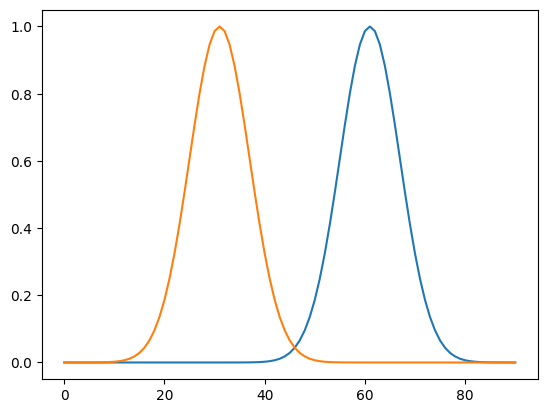

In [4]:
# plot the sim signal
for idx in range(len(data["sim_signal"])):
    plt.plot(data["sim_signal"][idx])

In [5]:
data.keys()

dict_keys(['sim_vertex', 'n_layers', 'sim_layers', 'patch_size', 'err_level', 'sim_patch_size', 'n_temp_modes_ebb', 'n_spatial_modes', 'hann_windowing_ebb', 'snr', 'dipole_moment', 'signal_width', 'sim_signal', 'win_size', 'sfreq', 'thickness', 'time', 'ts_ebb_layer', 'ts_slidwd_ebb_layer', 'fs_slidwd', 'fid_coords'])

In [6]:
n_layers = data["n_layers"]

In [7]:
# get the relative free energy 
fs_matrix = data['fs_slidwd']      # (n_rows, 11, 11)
relativeFs = np.array([
        fs_matrix[sim_idx, :] - fs_matrix[sim_idx, :].min()
        for sim_idx in range(fs_matrix.shape[0])
    ])

In [8]:
relativeFs.shape #(n_sim, n_layers)

(2, 11, 91)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


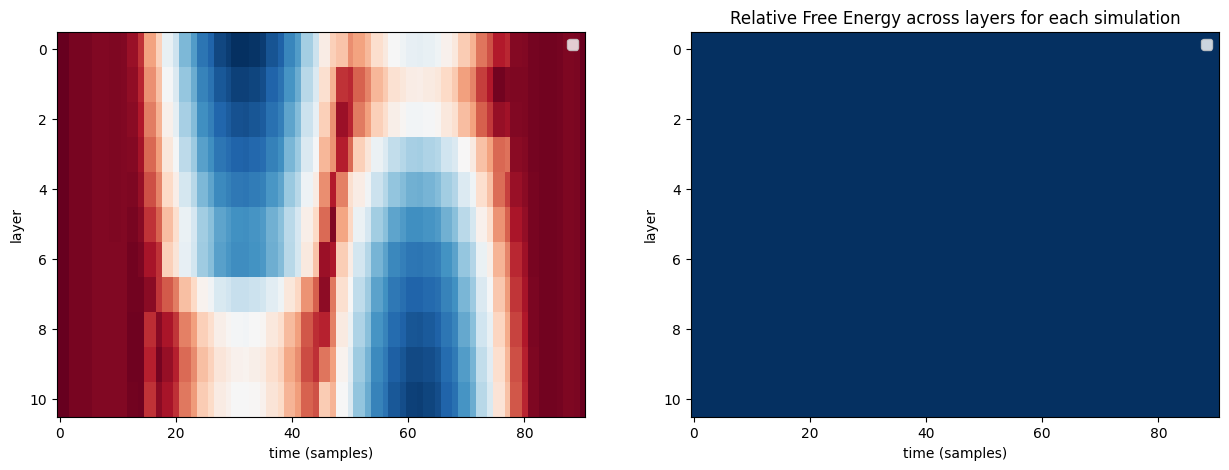

In [9]:
fig, ax = plt.subplots(1, relativeFs.shape[0], figsize=(15, 5))
for i in range(relativeFs.shape[0]):
    plot = ax[i].imshow(relativeFs[i], cmap="RdBu_r", aspect='auto')
    ax[i].set_xlabel('time (samples)')
    ax[i].set_ylabel('layer')
    ax[i].legend()
plt.title('Relative Free Energy across layers for each simulation')
plt.show()

In [10]:
# get the ebb matrix
sfreq = data['sfreq']
thickness = data['thickness']
ebb_matrix = data['ts_ebb_layer']      # (n_sim, n_layers)
csd_ebb = np.array([
        compute_csd(ebb_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.00012115276586285876
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01


ValueError: vmin, vcenter, and vmax must be in ascending order

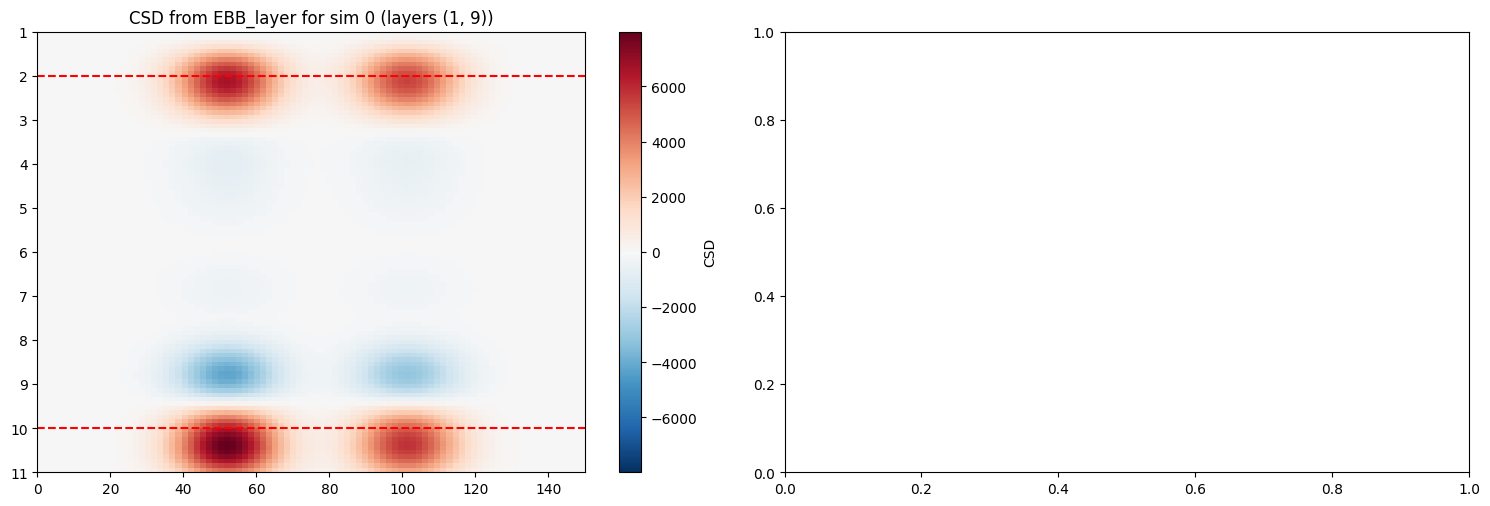

In [11]:
fig, ax = plt.subplots(1, csd_ebb.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb.shape[0]):
    plot_csd(csd_ebb[sim_idx, :], data["time"], ax[sim_idx])
    ax[sim_idx].set_title(f'CSD from EBB_layer for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')
    for layer in data["sim_layers"][sim_idx]:
        ax[sim_idx].axhline(layer/(n_layers-1), color='red', linestyle='--')

In [12]:
# get the ebb_layer matrix
ebb_layer_matrix = data['ts_slidwd_ebb_layer']      # (n_sim, n_layers)
csd_ebb_layer = np.array([
        compute_csd(ebb_layer_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_layer_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01


ValueError: vmin, vcenter, and vmax must be in ascending order

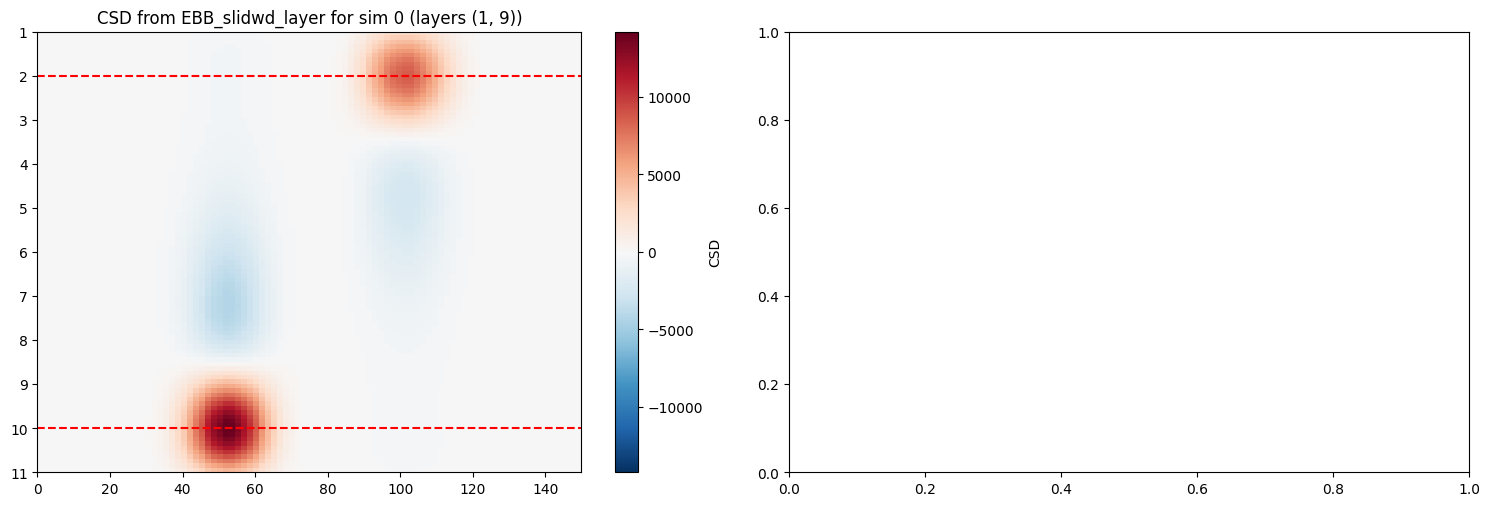

In [13]:
fig, ax = plt.subplots(1, csd_ebb_layer.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb_layer.shape[0]):
    plot_csd(csd_ebb_layer[sim_idx, :], data["time"], ax[sim_idx])
    ax[sim_idx].set_title(f'CSD from EBB_slidwd_layer for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')
    for layer in data["sim_layers"][sim_idx]:
        ax[sim_idx].axhline(layer/(n_layers-1), color='red', linestyle='--')